In [1]:
import cv2
import json
import numpy as np
import os
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# image size - must match ex. 1
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# path to my dataset
MY_DATASET_PATH = r'..\02-dataset'

MY_CONDITIONS = ['like', 'dislike', 'stop', 'rock', 'peace']

# load best model from ex. 1
model_part2 = load_model(r'..\01-hyperparameters\model_grayscale.keras')

## Load annotations
In this case, we have all annotations in one file.

In [5]:
with open(os.path.join(MY_DATASET_PATH, 'annotations', 'annot-martina.json')) as f:
    my_annotations = json.load(f)

## Loading and preprocessing images

In [6]:
def preprocess_image_new(img, color_space):
    img = cv2.cvtColor(img, color_space)
    img_resized = cv2.resize(img, SIZE)
    return img_resized


def load_my_images():
    images = []
    labels = []
    label_names = []

    for condition in MY_CONDITIONS:
        for filename in tqdm(os.listdir(os.path.join(MY_DATASET_PATH, condition)), desc=condition):
            UID = filename.split('.')[0]
            img = cv2.imread(os.path.join(MY_DATASET_PATH, condition, filename))
            if img is None:
                continue
            try:
                annotation = my_annotations[UID]
            except:
                continue
            for i, bbox in enumerate(annotation['bboxes']):
                x1 = int(bbox[0] * img.shape[1])
                y1 = int(bbox[1] * img.shape[0])
                w  = int(bbox[2] * img.shape[1])
                h  = int(bbox[3] * img.shape[0])
                crop = img[y1:y1+h, x1:x1+w]
                preprocessed = preprocess_image_new(crop, cv2.COLOR_BGR2GRAY)
                label = annotation['labels'][i]
                if label == "no_gesture":
                    continue
                if label not in label_names:
                    label_names.append(label)
                images.append(preprocessed)
                labels.append(label_names.index(label))

    return images, labels, label_names


my_images, my_labels, my_label_names = load_my_images()

like:   0%|          | 0/4 [00:00<?, ?it/s]

dislike:   0%|          | 0/4 [00:00<?, ?it/s]

stop:   0%|          | 0/4 [00:00<?, ?it/s]

rock:   0%|          | 0/4 [00:00<?, ?it/s]

peace:   0%|          | 0/4 [00:00<?, ?it/s]

## Prediction

In [7]:
# convert to numpy array, normalize and reshape
X = np.array(my_images).astype('float32') / 255.
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)  # 1 channel for grayscale

# make predictions
y_predictions = model_part2.predict(X)
y_predictions = np.argmax(y_predictions, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step


## Confusion matrix

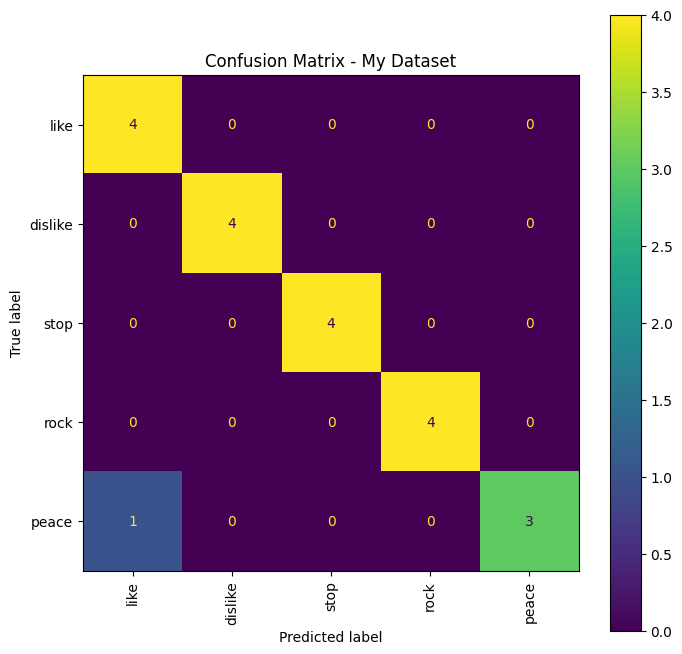

In [8]:
# create and plot confusion matrix
conf_matrix = confusion_matrix(my_labels, y_predictions)

fig = plt.figure(figsize=(8, 8))
ConfusionMatrixDisplay(conf_matrix, display_labels=my_label_names).plot(ax=plt.gca())
plt.title('Confusion Matrix - My Dataset')
plt.xticks(rotation=90, ha='center')

# save as required by the assignment
plt.savefig('conf-matrix.png', bbox_inches='tight')
plt.show()